In [24]:
using LinearAlgebra
using Plots
gr()
Plots.GRBackend()
filename = ""

include("Optimisation.jl")
include("Parameterization.jl")
include("RaySolver.jl")
include("PlotRays.jl")

segment (generic function with 1 method)

In [25]:
#controlx = [-1.5 -1.2 -0.7 -0.3 0. 0.3 0.7 1. 1.5]
#controly = [0. 0.1 0.5 0.3 0. 0.6 0.45 0.1 0.] .+ 1.
controlx = [-1.5 -0.7 -0.3 0. 0.3 0.7  1.5]
controly = [0.  0.5 0.3 0.1 0.6 0.45  0.] .+ 1.7
#controlx = [-1.5 0. 1.5]
#controly = [0.  0.1 0.] .+ 1.7
control = vcat(controlx, controly)
control0 = control

2×7 Matrix{Float64}:
 -1.5  -0.7  -0.3  0.0  0.3  0.7   1.5
  1.7   2.2   2.0  1.8  2.3  2.15  1.7

In [26]:
#movingcontrol = vcat([0.  0.  0.], [1.  0. 1.])
movingcontrol = vcat([0. 0.  0.  0.  0. 0.  0.  ], [0. 1. 1. 1. 1. 1. 1. ])

2×7 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  1.0  1.0  1.0  1.0  1.0  1.0

In [27]:
#Fonction coût écart à un point
# Jeu de rayons parallèles en entrée
Nray = 300
FOV = 15 # en degrés
FOV = FOV * pi / 180.
source0 = (Ray([0., 0. ], pi / 2. - FOV + 2 * FOV * i / Nray  ) for i in 0:Nray)

Base.Generator{UnitRange{Int64}, var"#79#80"}(var"#79#80"(), 0:300)

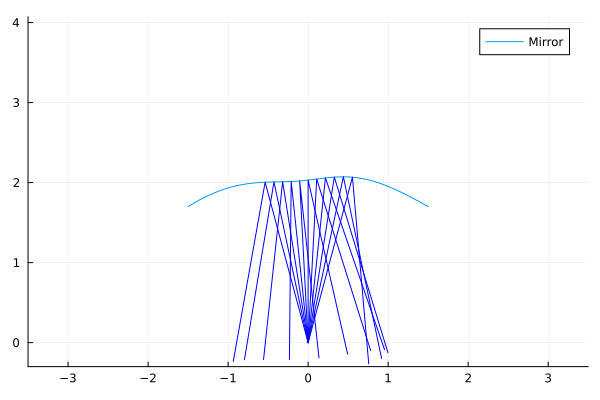

In [28]:
points = bezier(control, 0.)
for i in 1:100 
    points = hcat( points, bezier(control,i / 100)) 
end
#n = size(control)[2]
xlim = ( - maximum( -1. .*points[1,:] ) -2. , maximum( points[1,:] ) +2. )
ylim =  ( - maximum( -1. .*points[2,:] ) -2. , maximum( points[2,:] )  + 2. )
plt = plot(points[1,:],points[2,:], xlims = xlim, ylims =  ylim, aspect_ratio=:equal, label = "Mirror")
source4plot = (Ray([0., 0. ], pi / 2. - FOV + 2 * FOV * i / 10  ) for i in 0:10)
for ray in source4plot
    plot!(ray)
end
savefig("rays_verif_dir.png")
display(plt)

Fonction coût à minimiser dépendante des points de contrôle $\beta$:
$$
j_1(\beta) = \frac{1}{N_{ray}}\sum_{i=1}^{N_{ray}} |\xi_i(\beta) - \xi^*|^2
$$
avec $\xi_i(\beta) $  direction après réflexion du rayon $i$ pour le jeu de points de contrôle $\beta$. Dans une certaine mesure, cela revient à minimiser
$$
j_2(\beta) = \frac{1}{N_{ray}} \sum_{i=1}^{N_{ray}} |[\xi_i(\beta)]_1 - [\xi^*]_1|^2
$$
où $[\xi]_1$ désigne la première composante du vecteur $\xi$.

In [29]:
#Fonction coût
function cost0(control::Matrix{Float64})::Float64
    return  sum(  (cos(projectionplanfocal(billiard(control,ray) ).angle) - sqrt(2.) / 2.)^2 for ray in source0) / length(source0)
end
cost0(control)

0.38404079714675843

In [30]:
# Differentiel en x de la foinction cout sur le plan focal
function diffj0x(ray::Ray)::Vector{Float64}
    return [0., 0.]
end

# Differentiel en xi de la foinction cout sur le plan focal
function diffj0xi(ray::Ray)::Vector{Float64}
    return 2. .* [cos(ray.angle) - sqrt(2.)/2., 0. ]
end

# Differentiel en x de la foinction cout sur le miroir
function jtildex(ray::Ray)::Vector{Float64}
    rayf = projectionplanfocal(ray)
    return diffprojectionplanfocalx(ray, diffj0x(rayf), diffj0xi(rayf))
end

# Differentiel en xi de la foinction cout sur le miroir
function jtildexi(ray::Ray)::Vector{Float64}
    rayf = projectionplanfocal(ray)
    return diffprojectionplanfocalxi(ray, diffj0x(rayf), diffj0xi(rayf))
end


jtildexi (generic function with 1 method)

In [31]:
function cross2d(vec1::Vector{Float64}, vec2::Vector{Float64})::Real
    return vec1[1]* vec2[2] - vec1[2]* vec2[1] 
end
cross2d([0.,1.], [1.,0.])

-1.0

In [32]:
#### fusionner jtilde
### fusionner projection focal (matrice par bloc ? utiliser strcture de julia)
function gradientj0(control::Matrix{Float64})::Tuple{Matrix{Float64},Symmetric{Float64,Matrix{Float64}}}
    n::Int64 = size(control)[2] - 1  # Degree of the Béziers curve  
    gradient::Matrix{Float64} = zeros(2,n+1)
    dr2 = zeros(2*(n+1), 2*(n+1))
    for ray in source0
        # on projette sur le miroir et on récupère le $t$ de param
        t::Float64 = intersectionLine(control, ray) 
        dic = geometricquantities(control, t)
        theta = ray.angle
        #prendre un dangle et une normale sortante et renvoie l'angle correspondant au rayon réfléchi
        sdotn = dic["normal"][1] * cos(theta) + dic["normal"][2] * sin(theta)
        sdott = dic["utangent"][1] * cos(theta) + dic["utangent"][2] * sin(theta)
        thetaf = atan( sin(theta) - 2. * sdotn * dic["normal"][2], cos(theta) - 2. * sdotn * dic["normal"][1] )
        #on calcule les termes de la dérivée de formes
        sderterm = shapederivativeterms(control, t) #termes de la dérivée de formes
        rayr = Ray(dic["point"], thetaf)
        djx = jtildex(rayr)
        djxi = jtildexi(rayr)
        gradient += dot(dic["normal"], djx ) .*  sderterm["thetan"]
        gradient +=  ( sderterm["thetanprime"] * cross2d(dic["normal"], dic["utangent"]) .-  sderterm["thetan"] .* (dic["curvature"] * cross2d(dic["normal"], [cos(thetaf), sin(thetaf)]) / dot([cos(thetaf), sin(thetaf) ], dic["normal"])   ) ) * cross2d(djxi, [cos(thetaf), sin(thetaf)])
        
        #calculer terme ordre 2 pour LBMQ
        xi::Vector{Float64} = [cos(theta) ; sin(theta)]
        dxi::Vector{Float64} =  sdotn .* dic["utangent"] .+ sdott .* dic["normal"] 
        
        k::Int64 = 2* (n+1)
        ci::Int64 = 0
        li::Int64 = 0
        cj::Int64 = 0
        lj::Int64 = 0
        for i in 1:k
            ci = (i <= (n+1) ) * 1 + (i > (n+1) ) * 2
            li = (i <= (n+1) ) * i + (i > (n+1) ) * (i - (n+1) ) 
            ei = basiscontrol( n+1, ci, li  )
            for j in i:k
                cj = (j <= (n+1) ) * 1 + (j > (n+1) ) * 2
                lj = (j <= (n+1) ) * j + (j > (n+1) ) * (j -(n+1)) 
                if (movingcontrol[ci,li] == 0.)||(movingcontrol[cj,lj] ==  0.)
                    dr2[i,j] = 0.
                else
                    ej = basiscontrol( n+1, cj , lj )
                    
                    dx1::Vector{Float64} = dot(sderterm["thetan"], ei) .* xi ./ sdotn #  DB_1 ei
                    dxi1 = 2. .*  ( dot(  sderterm["thetanprime"]  .+ dic["curvature"] .* (sdott /sdotn) .* sderterm["thetan"] , ei)  ) .* dxi #  DB_2 ei
                    
                    dx2::Vector{Float64}  = dot(sderterm["thetan"], ej) .* xi ./ sdotn #  DB_1 ej
                    dxi2 = 2. .* ( dot(   sderterm["thetanprime"]  .+ dic["curvature"] .* (sdott /sdotn)  .*sderterm["thetan"] , ej)  ) .* dxi #  DB_2 ej
                    
                    dr2[i,j] += 2. * dxi1[1] * dxi2[1] 
                    #Ça c'est la vrai matrice comme si tous les points bougaient.
                end
            end
        end
        for i in 1:k 
            ci = (i <= (n+1) ) * 1 + (i > (n+1) ) * 2
            li = (i <= (n+1) ) * i + (i > (n+1) ) * (i - (n+1) ) 
            if (movingcontrol[ci,li] == 0.)
                    dr2[i,i] = length(source0)
            end
        end
    end
    return ( 2. * gradient ./ length(source0), Symmetric( dr2  ./ length(source0) ) )
end

#elle modifie la fonction initiale. Il faudrait mettre un !
function proj1(dj::Matrix{Float64})::Matrix{Float64}
    return movingcontrol .* dj 
end


proj1 (generic function with 1 method)

In [33]:
Niter = 150
step = 1.
#gradientj0(control)[2]

1.0

In [34]:
iter=Vector{Float64}(undef, 0)
cost=Vector{Float64}(undef, 0)
@elapsed control= LMdescent(cost0, gradientj0, control, norm, proj1, step, true, Niter)

Iteration number : 0
Le lambda est :0.2
La plus petite valeur propre est :1.1603781967492756e-5
Iteration number : 1
Le lambda est :0.04
La plus petite valeur propre est :8.937787467431875e-6
Iteration number : 2
Le lambda est :0.008
La plus petite valeur propre est :4.321088185643553e-6
Iteration number : 3
Le lambda est :0.0016
La plus petite valeur propre est :1.0338791341332138e-6
Iteration number : 4
Le lambda est :0.00032
La plus petite valeur propre est :2.601695719683871e-7
Iteration number : 5
Le lambda est :6.400000000000001e-5
La plus petite valeur propre est :1.7342335378987309e-7
Iteration number : 6
Le lambda est :1.2800000000000003e-5
La plus petite valeur propre est :8.175337124944435e-8
Iteration number : 7
Le lambda est :2.5600000000000005e-6
La plus petite valeur propre est :3.609987793594624e-8
Iteration number : 8
Le lambda est :5.120000000000001e-7
La plus petite valeur propre est :1.8367539221978605e-7
Iteration number : 9
Le lambda est :8.192000000000002e-7
La p

0.641424583

In [35]:
cost0(control)

3.7141519165891715e-9

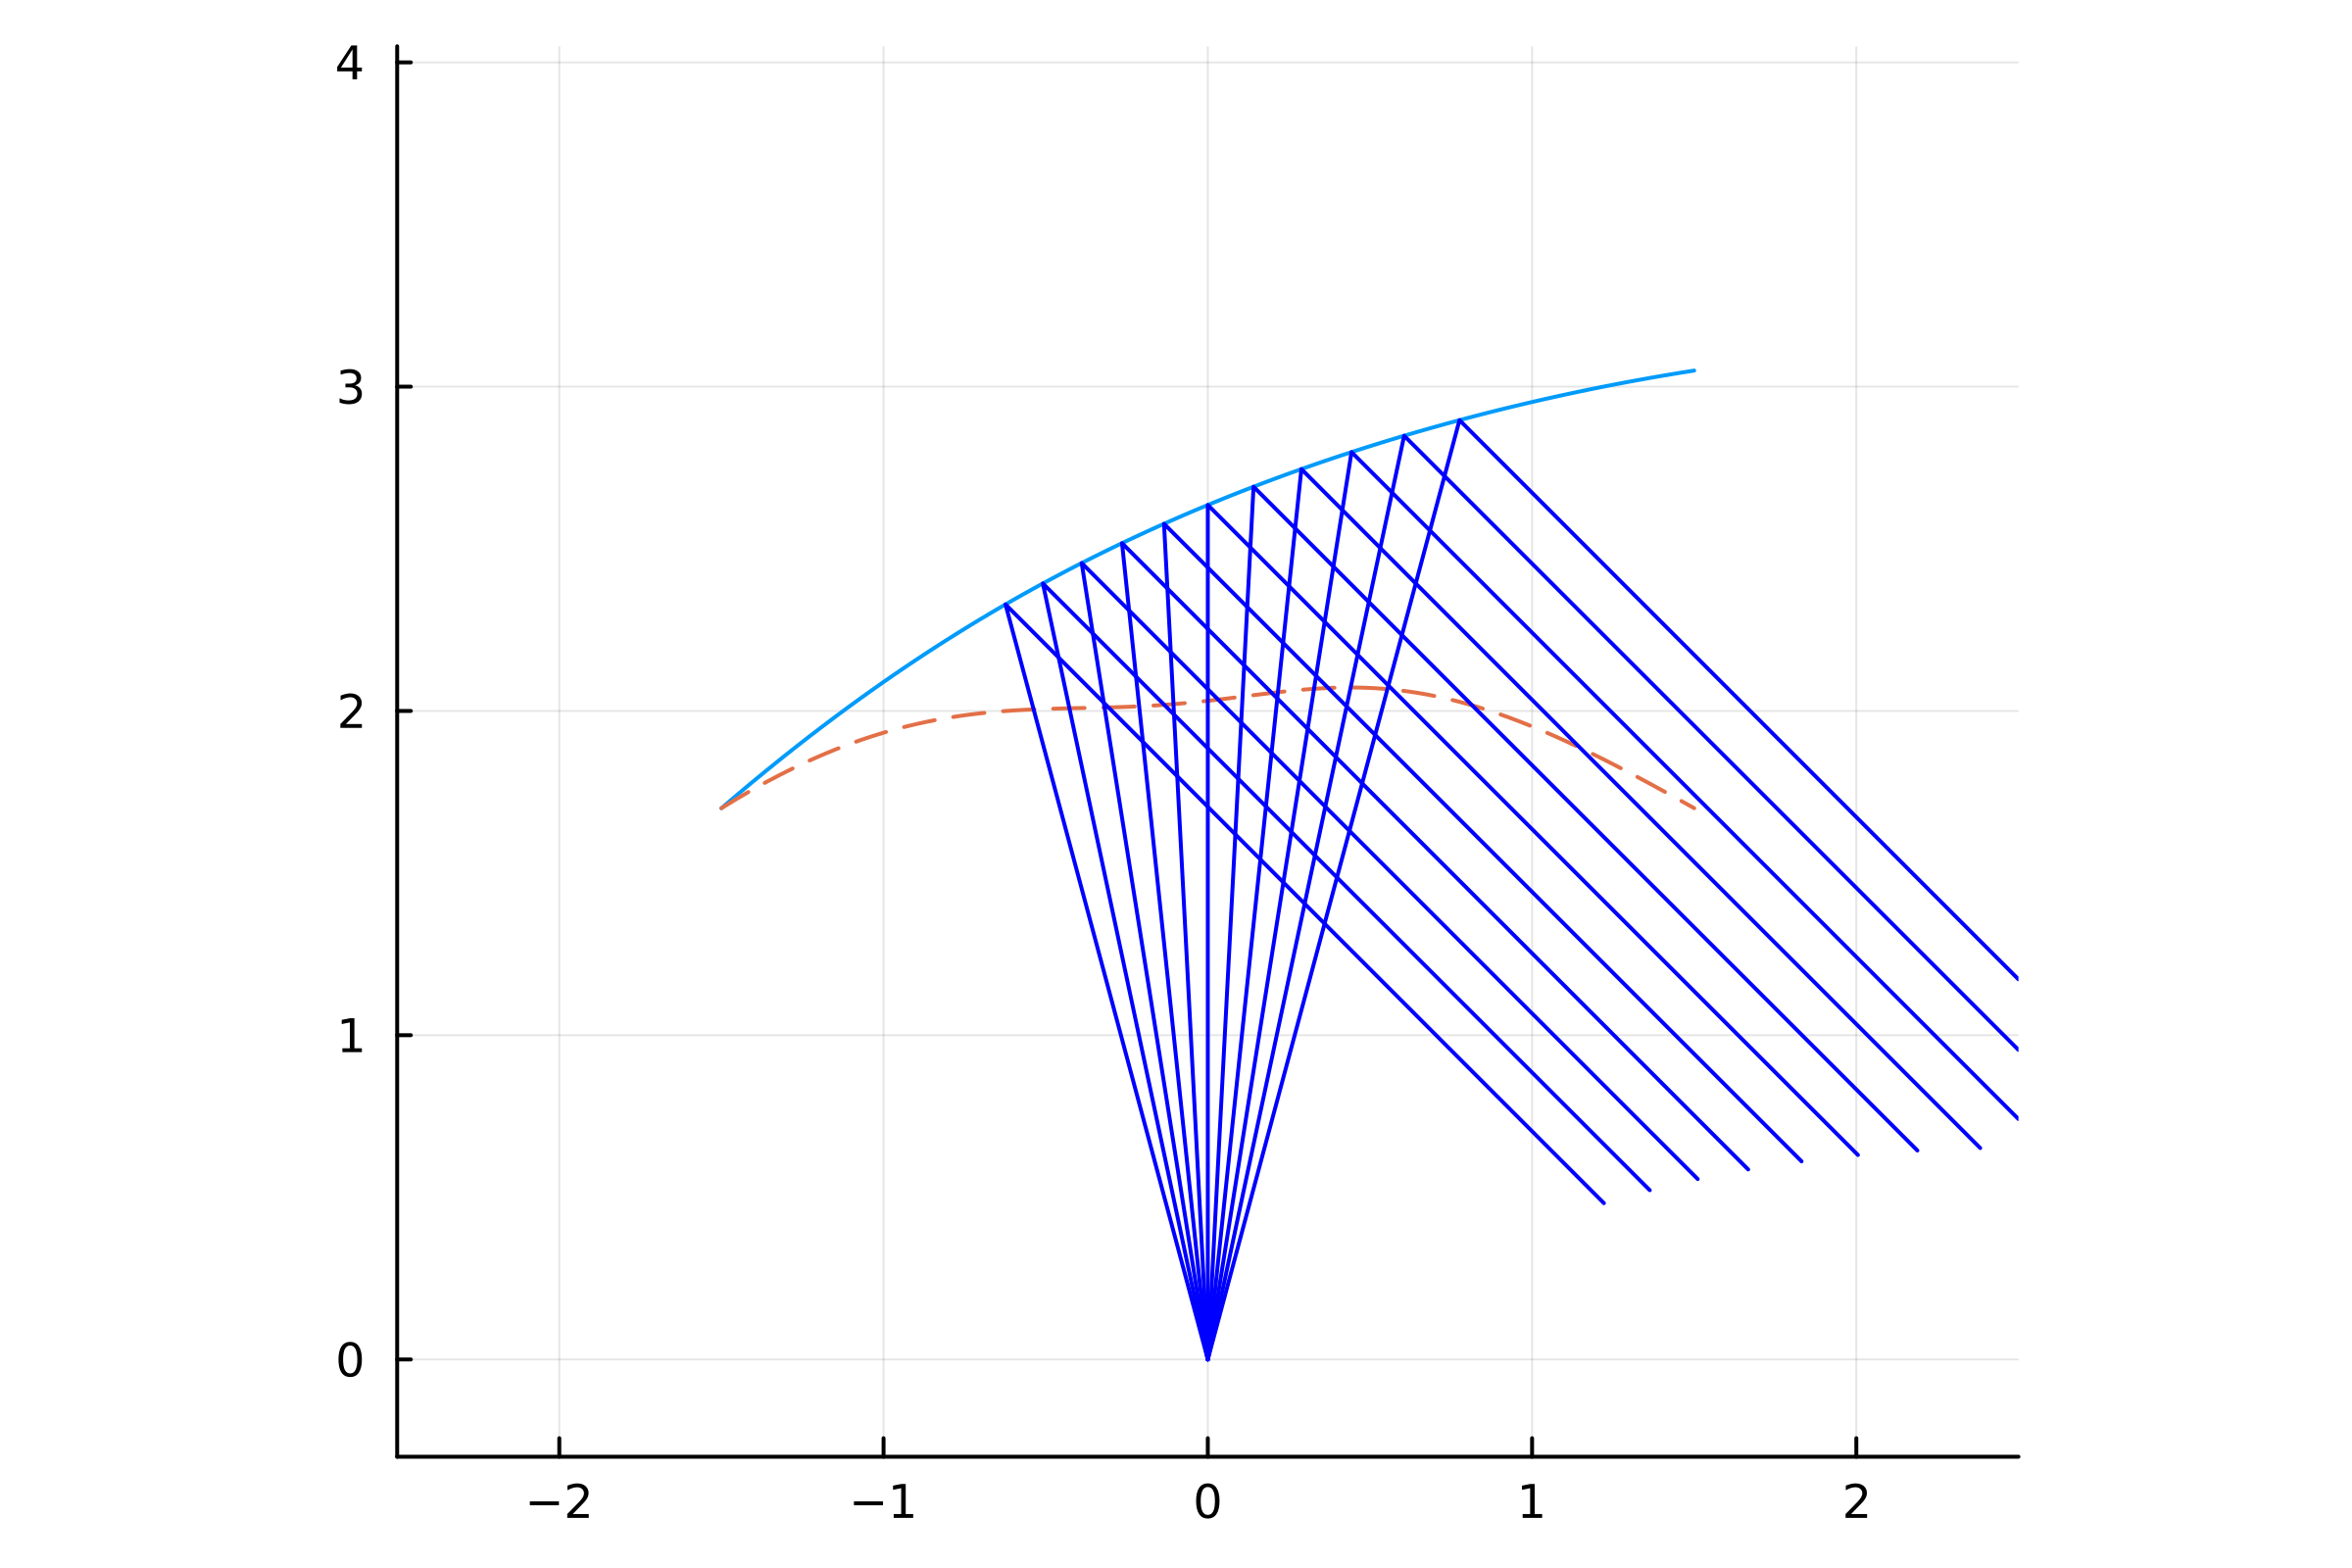

In [12]:
points = bezier(control, 0.)
points0 = bezier(control0, 0.)
for i in 1:100 
    points = hcat( points, bezier(control,i / 100)) 
    points0 = hcat( points0, bezier(control0,i / 100)) 
end
#n = size(control)[2]
xlim = ( - maximum( -1. .*points[1,:] ) -1. , maximum( points[1,:] ) +1. )
ylim =  ( - maximum( -1. .*points[2,:] ) -2. , maximum( points[2,:] )  + 1. )
plt = plot(points[1,:],points[2,:], xlims = xlim, ylims =  ylim, aspect_ratio=:equal, label = false, dpi = 400)
plot!(points0[1,:],points0[2,:], xlims = xlim, ylims =  ylim, aspect_ratio=:equal, label = false, linestyle=:dash)
for ray in source4plot
    plot!(ray)
end
savefig("direction_optim_final_rays_LVBM.png")
display(plt)

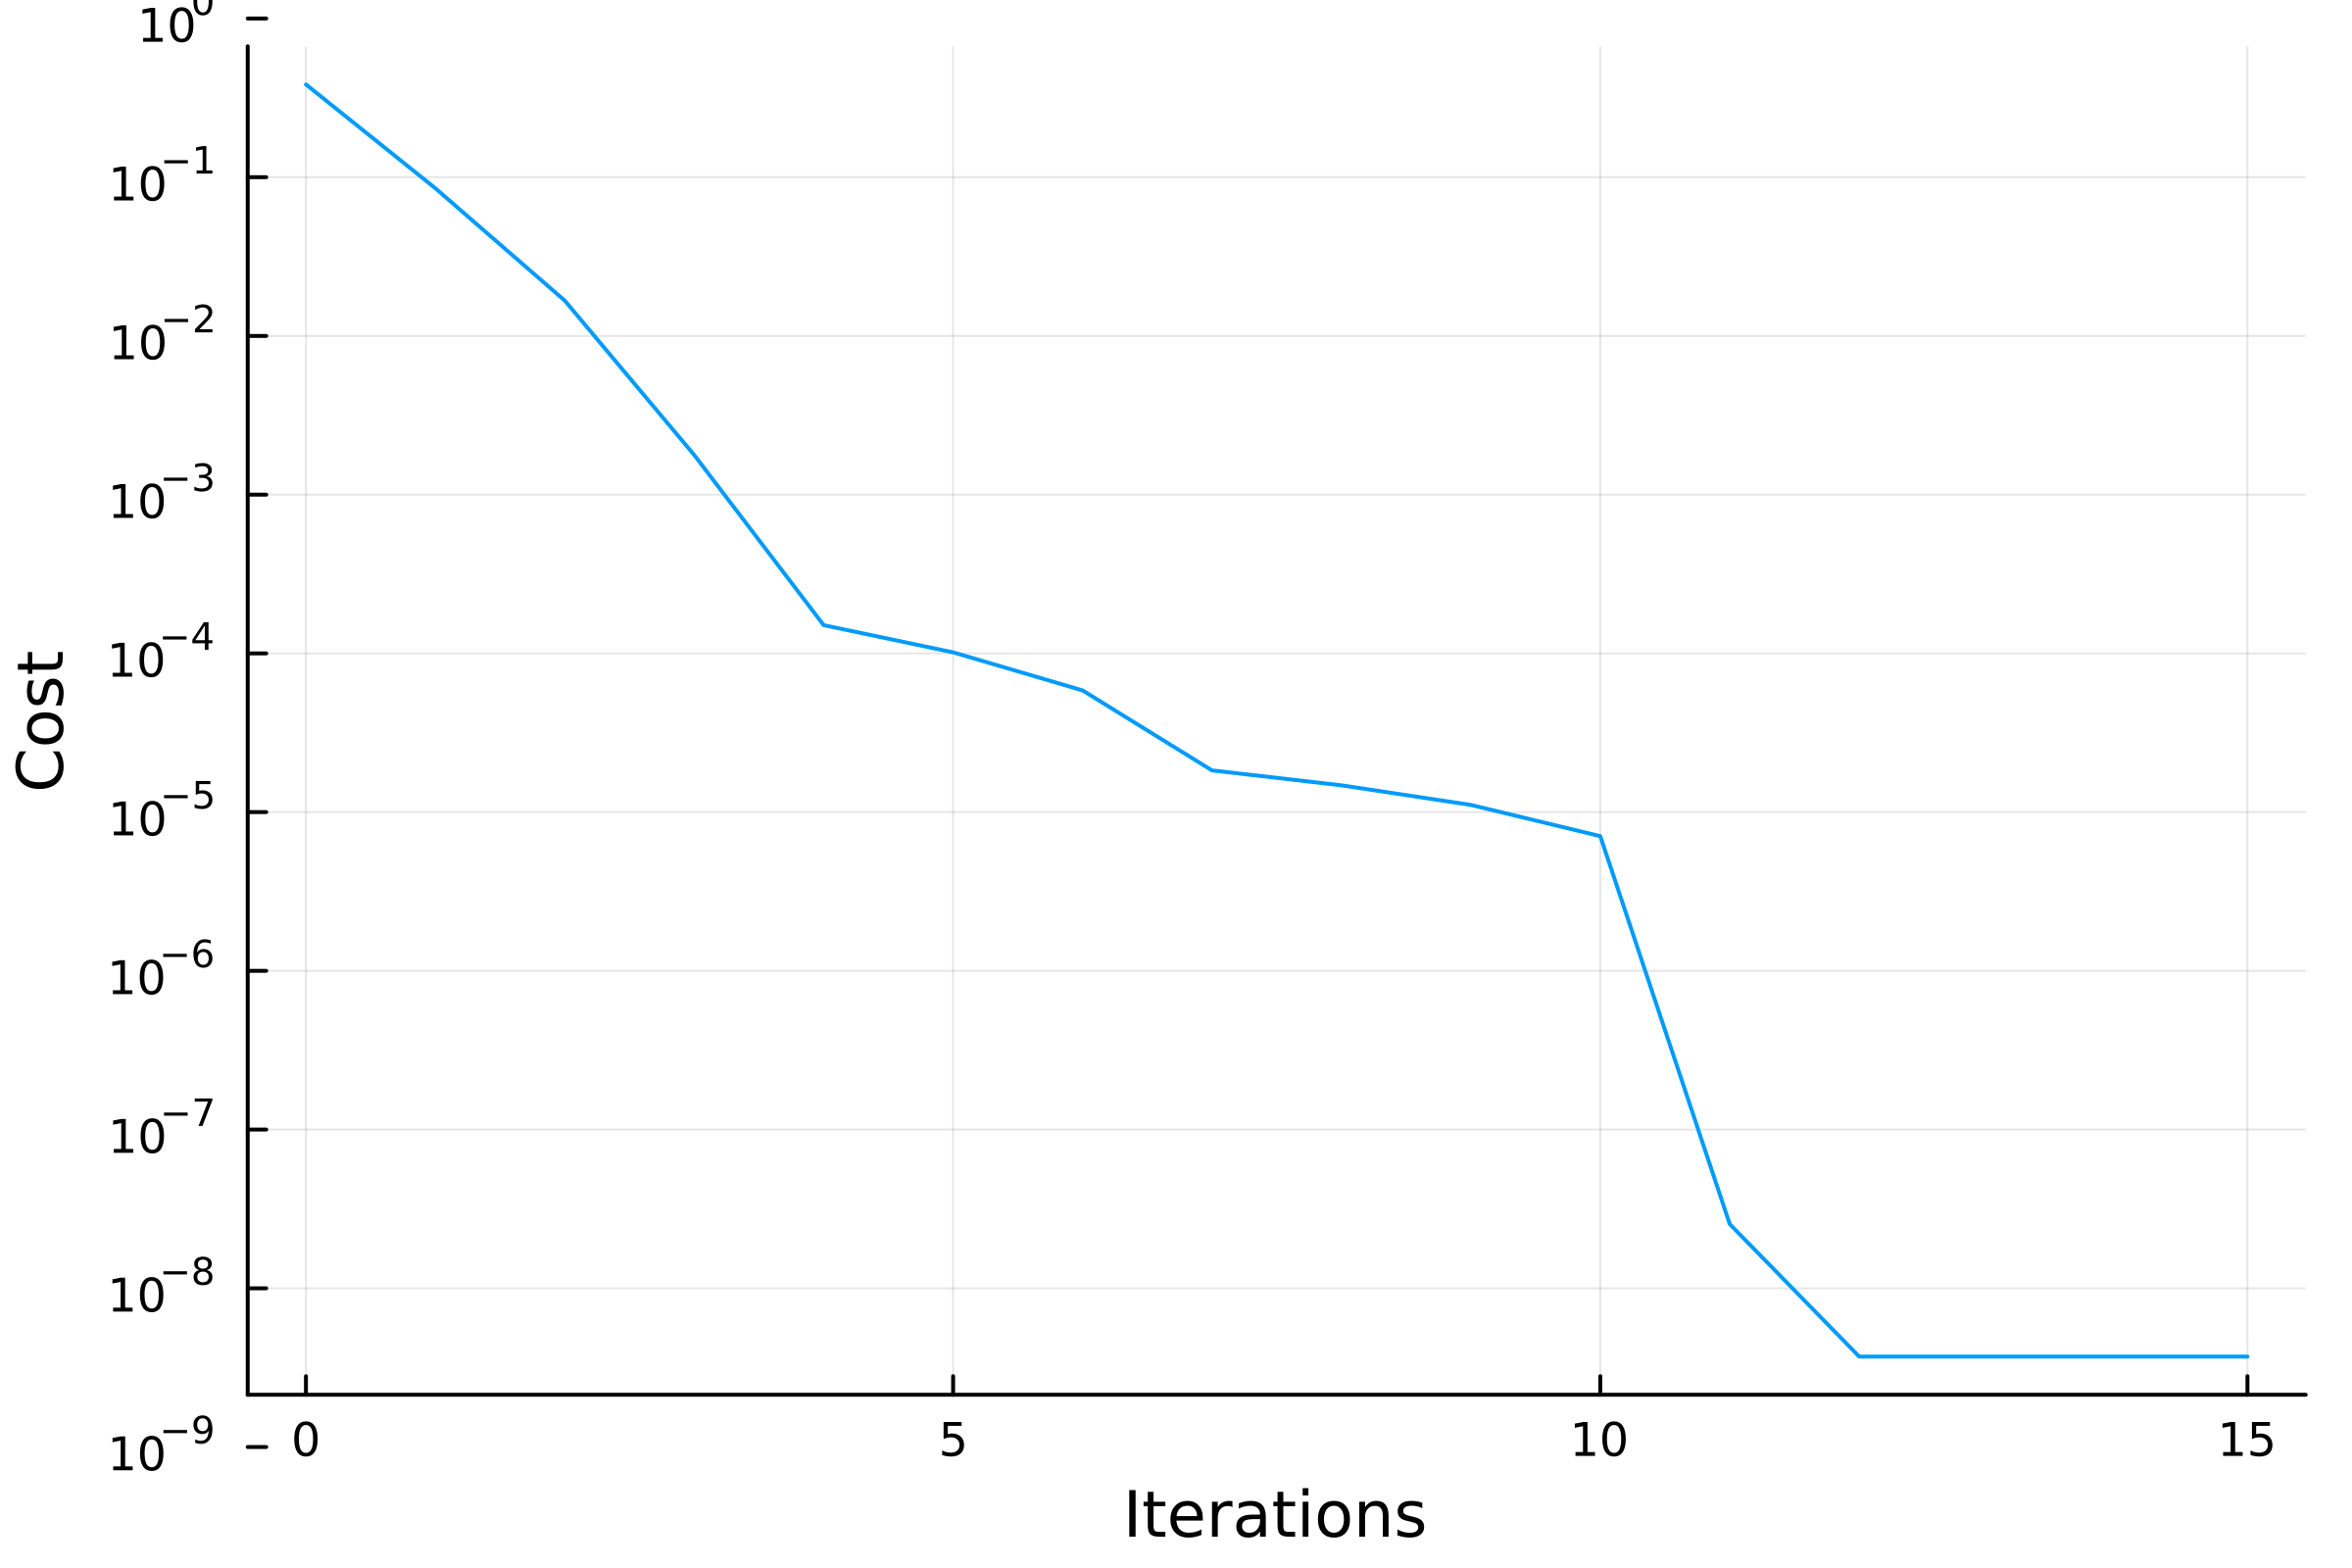

In [52]:
plt = plot(iter,cost, dpi = 400, yaxis =:log , legend = false, xlabel = "Iterations", ylabel = "Cost", yticks = 10)
savefig("convergence_history_direction_LVBM.png")
display(plt)

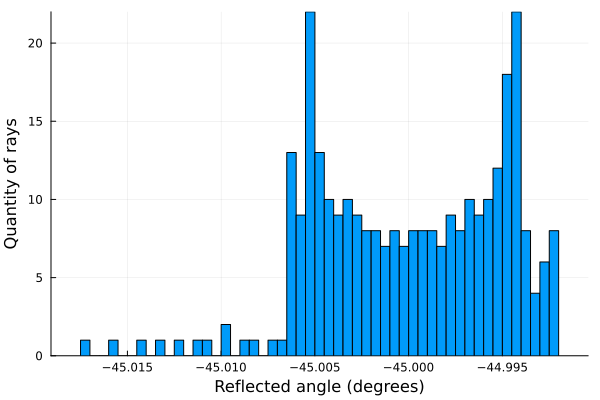

"/Users/lucagorini/Desktop/working_notes/RayTracingSolver_V2_2D/point_optim_final_rays_histo_LVBM.png"

In [53]:
angles = zeros(length(source0))
for (k,ray) in enumerate(source0)
    angles[k] = 180 * billiard(control,ray).angle / pi
end
hist = histogram(angles,bins = 50, label = false, xlabel = "Reflected angle (degrees)", ylabel = "Quantity of rays")
display(hist)
savefig("point_optim_final_rays_histo_LVBM.png")

In [54]:
# config initiale (avec rayons) 
# config initiale + optimisée sur le même miroir
# histogramme
# courbe de convergence
